# Домашнє завдання: Візуалізація даних з Matplotlib

## Опис завдання
У цьому домашньому завданні ви продовжите працювати з датасетом про оренду велосипедів `yulu_rental.csv`, але тепер будете використовувати бібліотеку Matplotlib для створення більш складних та налаштованих візуалізацій.

**Опис колонок:**
- `datetime` - дата та час
- `season` - квартал (1-Q1, 2-Q2, 3-Q3, 4-Q4)
- `holiday` - чи є день святковим (0=ні, 1=так)
- `workingday` - чи є день робочим (0=ні, 1=так)
- `weather` - погодні умови (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ)
- `temp` - температура в градусах Цельсія
- `atemp` - відчувається як температура
- `humidity` - вологість (%)
- `windspeed` - швидкість вітру
- `casual` - кількість випадкових користувачів
- `registered` - кількість зареєстрованих користувачів
- `count` - загальна кількість орендованих велосипедів

## Підготовка даних

---


🌱 Коментар щодо сезонності

Колонка season у датасеті представляє саме квартали року, а не метеорологічні сезони. Тому всі аналізи сезонності ви можете будувати на основі кварталів.

Водночас дані були зібрані в Індії, де поділ на сезони інший, ніж у Європі чи США. Якщо ви хочете дослідити сезонність відповідно до індійської системи сезонів, можна створити окрему колонку.

Справжні сезони в Індії:

| Сезон        | Місяці                     |
| ------------ | -------------------------- |
| Winter       | December–February (12,1,2) |
| Summer       | March–May (3,4,5)          |
| Monsoon      | June–September (6,7,8,9)   |
| Post-monsoon | October–November (10,11)   |


Тоді потрібно зробити нову колонку weather_season_india, мапнувши місяці так:

12, 1, 2 → 1 (Winter)

3, 4, 5 → 2 (Summer)

6–9 → 3 (Monsoon)

10–11 → 4 (Post-Monsoon)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Завантаження даних
df = pd.read_csv('../data/yulu_rental.csv')
df['datetime'] = pd.to_datetime(df['datetime'])
df.set_index('datetime', inplace=True)

# Додаткові колонки
df['month'] = df.index.month
df['hour'] = df.index.hour
df['weekday'] = df.index.day_name()
df['weekday_num'] = df.index.weekday
df['week'] = df.index.isocalendar().week
df['year'] = df.index.year
df['day'] = df.index.day

In [4]:
df.head()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,month,hour,weekday,weekday_num,week,year,day
datetime,,,,,,,,,,,,,,,,,,
2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16,1,0,Saturday,5,52,2011,1
2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40,1,1,Saturday,5,52,2011,1
2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32,1,2,Saturday,5,52,2011,1
2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13,1,3,Saturday,5,52,2011,1
2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1,1,4,Saturday,5,52,2011,1


## Завдання 1: Порівняння Pandas vs Matplotlib

**Завдання:**
Побудуйте лінійний графік середньої кількості оренд помісячно впродовж всього періоду в даних двома способами:
1. Використовуючи Pandas (DataFrame.plot())
2. Використовуючи Matplotlib безпосередньо

В обох методах додайте маркери-кружечки. Можна також задати свій відмінний від стандартного колір.

Підказка: отримати потрібний формат даних найзручніше з методом датафрейму `resample`.

**Опишіть свої спостереження:** чим відрізняються 2 побудованих графіки? Який вам більше подобається?

In [3]:
monthly_rent = df['count'].resample('ME').mean()
monthly_rent 

datetime
2011-01-31     54.645012
2011-02-28     73.641256
2011-03-31     86.849776
2011-04-30    111.026374
2011-05-31    174.809211
2011-06-30    196.877193
2011-07-31    203.614035
2011-08-31    182.666667
2011-09-30    174.622517
2011-10-31    174.773626
2011-11-30    155.458333
2011-12-31    134.173246
2012-01-31    124.353201
2012-02-29    145.646154
2012-03-31    208.276923
2012-04-30    257.455947
2012-05-31    264.109649
2012-06-30    287.186404
2012-07-31    267.037281
2012-08-31    285.570175
2012-09-30    292.598684
2012-10-31    280.508772
2012-11-30    231.980220
2012-12-31    217.054825
Freq: ME, Name: count, dtype: float64

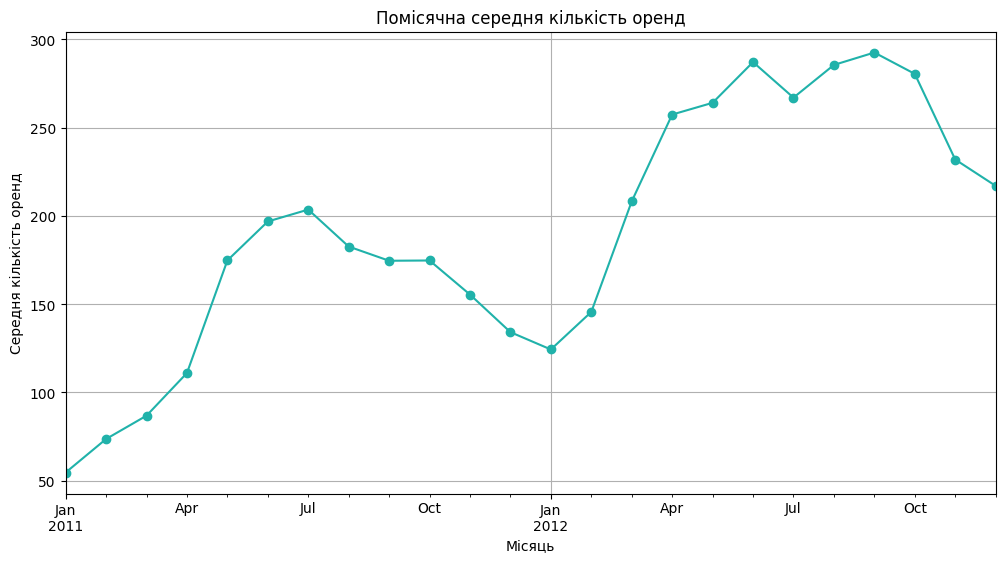

In [38]:
monthly_rent.plot(
    kind='line',
    color='#20B2AA',
    marker='o',
    figsize=(12, 6),
    title='Помісячна середня кількість оренд',
    xlabel='Місяць',
    ylabel='Середня кількість оренд',
    grid=True 
);

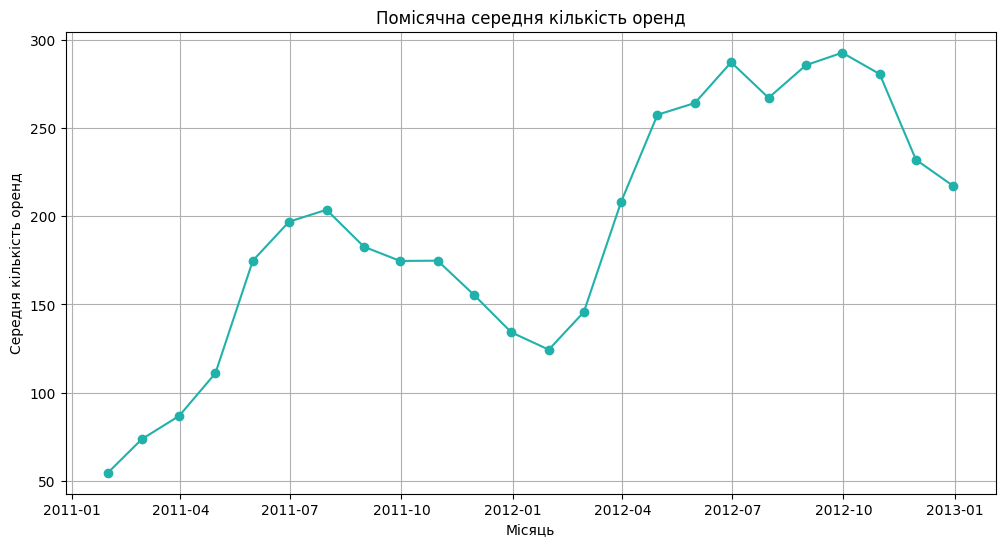

In [39]:
plt.figure(figsize=(12, 6))
plt.plot(monthly_rent, 'o-', color='#20B2AA')
plt.title('Помісячна середня кількість оренд')
plt.xlabel('Місяць')
plt.ylabel('Середня кількість оренд')
plt.grid(True);

**Спостереження**

Мені більше подобається Pandas, оскільки він вимагає менше коду і самостійно дбає про підписи осей та зрозумілий формат дат. Проте Matplotlib корисний, коли потрібно налаштувати кожну дрібницю графіка індивідуально."

## Завдання 2: Робота зі списками та numpy

**Завдання:**
Вам задані 3 списки:
1. Номер дня тижня.
2. Продажі в тиждень 1.
3. Продажі в тиждень 2.

Створіть графік, на якому лінійними графіками різних кольорів накладено продажі за обидва тижні.

Обовʼязково додайте назву графіку, підписи вісям ОХ, ОУ, назви кожного з рядів даних, легенду.

**Дайте відповіді на питання**
1. Судячи з графіку, в який тиждень проодажі були стабільніше?
2. Чи можете ви підкріпити свій висновок обчисленнями? Якими саме? Можна (але не обовʼязково) навести ці обчислення.

In [11]:
# Дані у вигляді списків
days = [1, 2, 3, 4, 5, 6, 7] # 1 - це понеділок
sales_week1 = [1349,1562,1600,1606,1510,959,822]  # Продажі за тиждень1
sales_week2 = [1321,1263,1162,1406,1421,1248,1204]  # Продажі за тиждень1

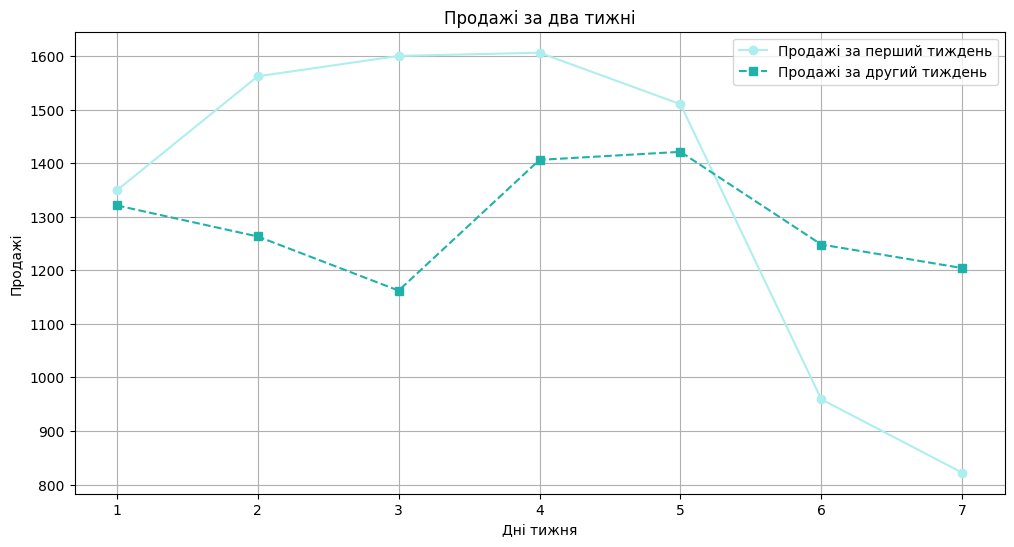

In [40]:
plt.figure(figsize=(12, 6))
plt.plot(days, sales_week1, ls='-', marker='o', color='#AFEEEE', label='Продажі за перший тиждень')
plt.plot(days, sales_week2, ls='--', marker='s', color='#20B2AA', label='Продажі за другий тиждень')

plt.title('Продажі за два тижні')
plt.xlabel('Дні тижня')
plt.ylabel('Продажі')
plt.grid(True)
plt.legend()

plt.show()

**Судячи з графіку, в який тиждень проодажі були стабільніше?**

Судячи з графіку, продажі були стабільнішими у другий тиждень. Лінія виглядає більш пологим "зигзагом". Немає таких глибоких провалів, значення коливаються у вужчому діапазоні.

**Чи можете ви підкріпити свій висновок обчисленнями? Якими саме? Можна (але не обовʼязково) навести ці обчислення.**

Можна перевірити за допомогою стандартного відхилення або розмаху.

In [32]:
s1 = np.array(sales_week1)
s2 = np.array(sales_week2)

print(f"Розмах тижня 1: {s1.max() - s1.min()}")
print(f"Розмах тижня 2: {s2.max() - s2.min()}")

std1 = np.std(sales_week1)
std2 = np.std(sales_week2)

print(f"Стандартне відхилення тиждень 1: {std1:.2f}")
print(f"Стандартне відхилення тиждень 2: {std2:.2f}")

Розмах тижня 1: 784
Розмах тижня 2: 259
Стандартне відхилення тиждень 1: 300.00
Стандартне відхилення тиждень 2: 90.91


У другому тижні різниця між найкращим та найгіршим показником значно менша, так само як і страндартне відхилення. Це свідчить про стабільність.

## Завдання 3: Subplot - 2x2 сітка графіків

**Завдання:**
Створіть сітку 2x2 з чотирма різними графіками, використовуючи `plt.subplot()`:
1. Лінійний графік середньої температури помісячно.
2. Стовпчикова діаграма середньої годинної кількості оренд за кварталами.
3. Гістограма вологості за всіма погодинними вимірами.
4. Scatter plot температури vs кількості оренд.

Кожен підграфік має містити всі необхідні підписи. Дашборд має містити назву.

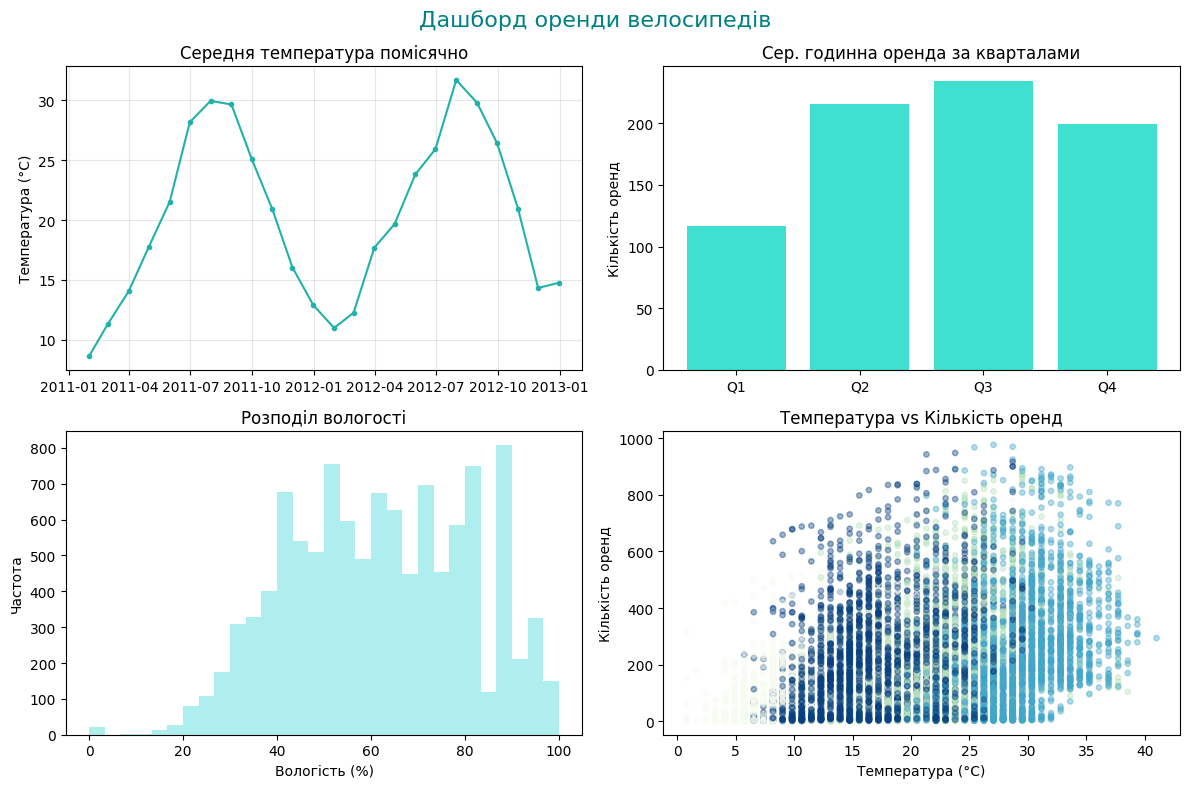

In [45]:
plt.figure(figsize=(12, 8))
plt.suptitle('Дашборд оренди велосипедів', fontsize=16, color='#008080')

# Лінійний графік
plt.subplot(2, 2, 1)
monthly_temp = df['temp'].resample('ME').mean()
plt.plot(monthly_temp, color='#20B2AA', marker='.')
plt.title('Середня температура помісячно')
plt.ylabel('Температура (°C)')
plt.grid(True, alpha=0.3)

# Стовпчиковий графік
plt.subplot(2, 2, 2)
seasonal_avg = df.groupby('season')['count'].mean()
quarters = ['Q1', 'Q2', 'Q3', 'Q4']
plt.bar(quarters, seasonal_avg, color='#40E0D0')
plt.title('Сер. годинна оренда за кварталами')
plt.ylabel('Кількість оренд')

# Гістограма
plt.subplot(2, 2, 3)
plt.hist(df['humidity'], bins=30, color='#AFEEEE')
plt.title('Розподіл вологості')
plt.xlabel('Вологість (%)')
plt.ylabel('Частота')

# Scatter plot
plt.subplot(2, 2, 4)
plt.scatter(df['temp'], df['count'], s=15, c=df['season'], cmap='GnBu', alpha=0.4)
plt.title('Температура vs Кількість оренд')
plt.xlabel('Температура (°C)')
plt.ylabel('Кількість оренд')

plt.tight_layout()
plt.show()

## Завдання 4: Subplots - об'єктно-орієнтований підхід

**Завдання:**
Створіть той самий набір графіків, але використовуючи `fig, ax = plt.subplots()`.

**Дайте відповідь на питання своїми словами**
- Чим відрізняється підхід побудови кількох графіків на одній фігурі з `plt.subplots()` від `plt.subplot()`?

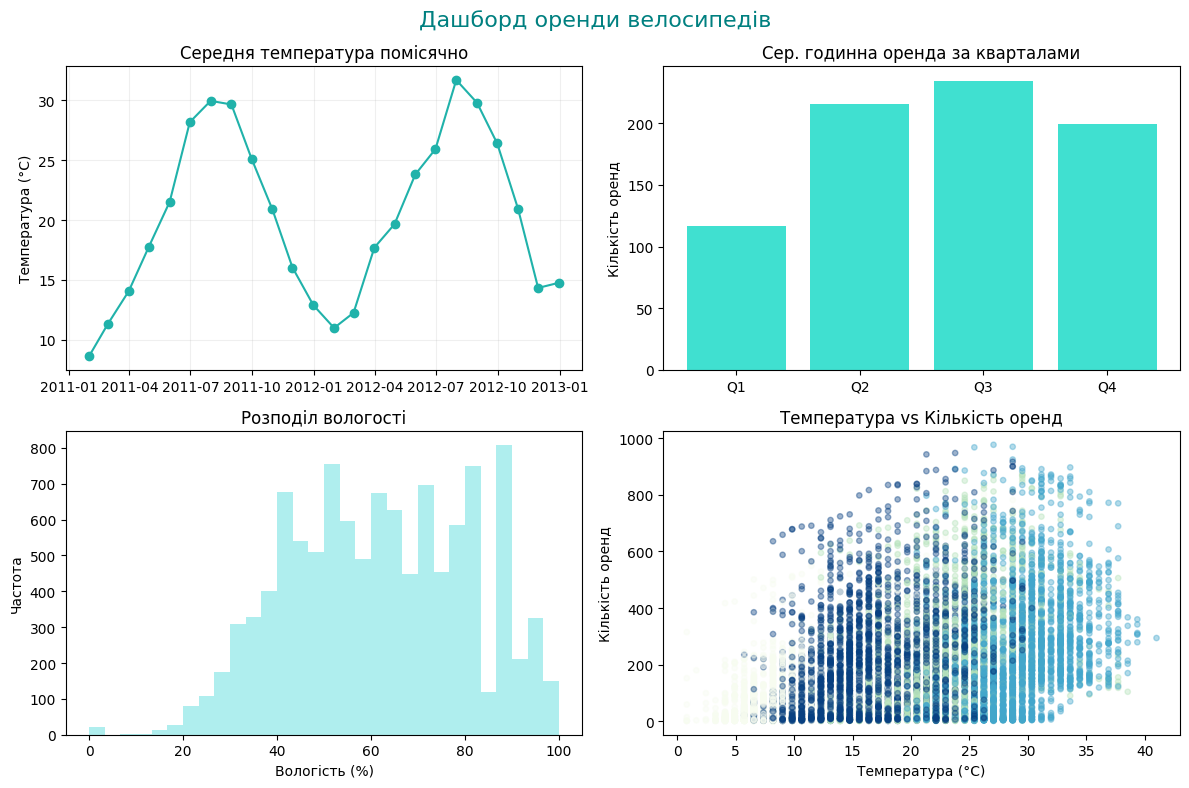

In [48]:
fig, ax = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Дашборд оренди велосипедів', fontsize=16, color='#008080')

# 1: Лінійний
monthly_temp = df['temp'].resample('ME').mean()
ax[0, 0].plot(monthly_temp, color='#20B2AA', marker='o')
ax[0, 0].set_title('Середня температура помісячно')
ax[0, 0].set_ylabel('Температура (°C)')
ax[0, 0].grid(True, alpha=0.2)

#2: Стовпчиковий
seasonal_avg = df.groupby('season')['count'].mean()
quarters = ['Q1', 'Q2', 'Q3', 'Q4']
ax[0, 1].bar(quarters, seasonal_avg, color='#40E0D0')
ax[0, 1].set_title('Сер. годинна оренда за кварталами')
ax[0, 1].set_ylabel('Кількість оренд')

# 3: Гістограма 
ax[1, 0].hist(df['humidity'], bins=30, color='#AFEEEE')
ax[1, 0].set_title('Розподіл вологості')
ax[1, 0].set_xlabel('Вологість (%)')
ax[1, 0].set_ylabel('Частота')

# 4: Scatter Plot 
ax[1, 1].scatter(df['temp'], df['count'], s=15, c=df['season'], cmap='GnBu', alpha=0.4)
ax[1, 1].set_title('Температура vs Кількість оренд')
ax[1, 1].set_xlabel('Температура (°C)')
ax[1, 1].set_ylabel('Кількість оренд')

plt.tight_layout()
plt.show()

**Чим відрізняється підхід побудови кількох графіків на одній фігурі з plt.subplots() від plt.subplot()**

Основна різниця полагає у синтаксису, проте plt.subplots() як на мене є комфортнішим в плані локалізації "комірки" з графіком над яким працюєш. Тобто, мені ax[0, 0] є комфортнішим ніж (2, 2, 1).

## (Опціонально) Завдання 5: Тонкі налаштування форматування графіка

**Завдання:**
Подібно до прикладу, наведеного в лекції, створіть професійно оформлений графік помісячної динаміки оренди з максимальною кількістю деталей та налаштувань. Ваш графік має включати:

**Обов'язкові елементи:**
1. **Три лінії:** середнє, максимум, мінімум за місяцями
2. **Різні стилі ліній:** суцільна, пунктирна, крапкова + різні маркери
3. **Заливка області** між мінімумом та максимумом
4. **Дві анотації:** для найвищого та найнижчого середнього значення
5. **Горизонтальна лінія** середнього за весь рік
6. **Двошарова сітка:** основна та допоміжна
7. **Стилізована легенда** з тінню
8. **Текстовий блок** зі статистикою в кутку графіка
9. **Професійне оформлення:** заголовки, підписи осей з жирним шрифтом

**Результат:** Графік повинен виглядати як готова ілюстрація для бізнес-звіту або наукової публікації.

Приклад очікуваного результату.
![](https://drive.google.com/uc?id=1YoJByivzlqncEF2zbWu3EhGSZ7XRme8T)


**Питання для інтерпретації:**
1. Яка перевага додавання анотацій на графік?
2. Для чого використовується fill_between()?
3. Як текстовий блок допомагає в інтерпретації даних?

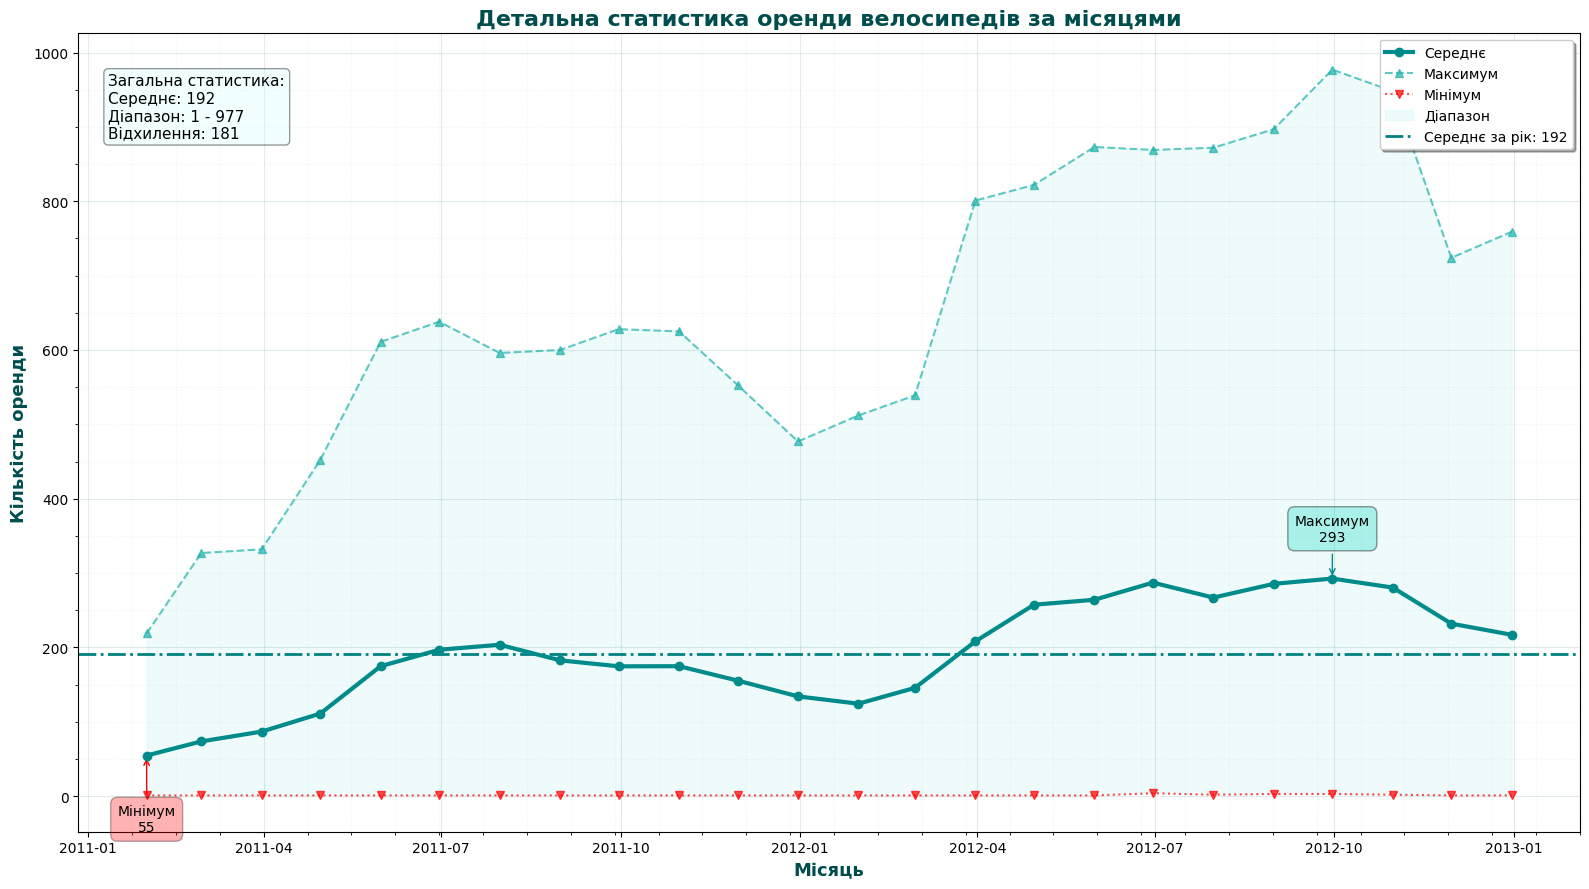

In [57]:
resampled = df['count'].resample('ME')
monthly_mean = resampled.mean()
monthly_max = resampled.max()
monthly_min = resampled.min()
overall_mean = df['count'].mean()

fig, ax = plt.subplots(figsize=(16, 9))

#Основні показники
ax.plot(monthly_mean, color='#008B8B', label='Середнє', marker='o', linewidth=3, zorder=5) 
ax.plot(monthly_max, color='#20B2AA', label='Максимум', linestyle='--', marker='^', alpha=0.7) 
ax.plot(monthly_min, color='r', label='Мінімум', linestyle=':', marker='v', alpha=0.7) 

#Сер. та діапазон
ax.fill_between(monthly_mean.index, monthly_min, monthly_max, color='#AFEEEE', alpha=0.2, label='Діапазон')
ax.axhline(overall_mean, color='#008080', linestyle='-.', linewidth=2, label=f'Середнє за рік: {overall_mean:.0f}')

# Піки
max_val = monthly_mean.max()
max_date = monthly_mean.idxmax()
min_val = monthly_mean.min()
min_date = monthly_mean.idxmin()

ax.annotate(f'Максимум\n{max_val:.0f}', xy=(max_date, max_val), xytext=(0, 25),
            textcoords='offset points', ha='center', va='bottom',
            bbox=dict(boxstyle='round,pad=0.5', fc='#40E0D0', alpha=0.4),
            arrowprops=dict(arrowstyle='->', color='#008B8B'))

ax.annotate(f'Мінімум\n{min_val:.0f}', xy=(min_date, min_val), xytext=(0, -35),
            textcoords='offset points', ha='center', va='top',
            bbox=dict(boxstyle='round,pad=0.5', fc='r', alpha=0.3), 
            arrowprops=dict(arrowstyle='->', color='r'))

# Блок зі статистикою
stats_text = (f"Загальна статистика:\n"
              f"Середнє: {overall_mean:.0f}\n"
              f"Діапазон: {df['count'].min()} - {df['count'].max()}\n"
              f"Відхилення: {df['count'].std():.0f}")
ax.text(0.02, 0.95, stats_text, transform=ax.transAxes, fontsize=11,
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='#E0FFFF', alpha=0.4))

# Налаштування сітки та осей
ax.set_title('Детальна статистика оренди велосипедів за місяцями', fontsize=16, fontweight='bold', color='#004d4d')
ax.set_xlabel('Місяць', fontsize=13, fontweight='bold', color='#004d4d')
ax.set_ylabel('Кількість оренди', fontsize=13, fontweight='bold', color='#004d4d')

ax.grid(True, which='major', linestyle='-', alpha=0.2, color='#5F9EA0')
ax.grid(True, which='minor', linestyle=':', alpha=0.1, color='#5F9EA0')
ax.minorticks_on()

# Легенда
ax.legend(loc='upper right', shadow=True, fontsize=10, facecolor='w')

plt.tight_layout()
plt.show()

**Яка перевага додавання анотацій на графік?**
Анотації дозволяють миттєво сфокусувати увагу на критично важливих показниках. Вони позбавляють необхідності шукати точні значення на осях.

**Для чого використовується fill_between()?**

Щоб показати розкид даних. Вона показує, наскільки фактичні значення можуть відрізнятися від середнього.

**Як текстовий блок допомагає в інтерпретації даних?**

Він надає контекст, який допомагає правильно зчитувати дані графіка.
